# **Project: Smart Fraud Detection Pipeline**
## **Fraud Analytics & Visualization**


**Author:** Snehal A. Bhosale  
**College:** Sanjivani College of Engineering, Kopargaon  
**Email:** snehalbhosale1807@gmail.com  
**Student ID:** CT_CSI_DE_1177  
**Technology:** PySpark, Spark SQL, Parquet/Delta Lake

## **Objective:**
To analyze the Gold fraud detection results and generate meaningful
business insights through fraud summaries, account-level analysis,
fraud-type analysis, merchant analysis, risk analysis and visualizations.

### **Step 2. Import Libraries**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    count,
    sum,
    round,
    desc
)
import matplotlib.pyplot as plt

### **Step 3. Start Spark**

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("SmartFraudDetection_Analytics")
    .getOrCreate()
)

print("Spark started successfully")
print("Spark Version:", spark.version)

Spark started successfully
Spark Version: 4.0.3


### **Step 4. Upload Gold Data**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving gold_fraud_per_account.csv to gold_fraud_per_account.csv
Saving gold_fraud_summary.csv to gold_fraud_summary.csv
Saving gold_fraud_transactions.csv to gold_fraud_transactions.csv


### **Step 5. Read Dataset**

In [ ]:
gold_transactions = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("gold_fraud_transactions.csv")
)

In [ ]:
print("Gold Records:", gold_transactions.count())
gold_transactions.show(5, truncate=False)

Gold Records: 20004
+---------+----------+--------+---------+----------+----------+------------+----------+----------+
|txn_id   |account_id|amount  |merchant |txn_date  |fraud_type|flagged_date|fraud_flag|risk_level|
+---------+----------+--------+---------+----------+----------+------------+----------+----------+
|TXN000001|ACC0065   |45458.55|Flipkart |2025-06-10|NULL      |NULL        |normal    |Low       |
|TXN000002|ACC0258   |25336.95|Swiggy   |2025-06-14|NULL      |NULL        |normal    |Low       |
|TXN000003|ACC0088   |93690.65|BigBasket|2025-06-18|NULL      |NULL        |normal    |Low       |
|TXN000004|ACC0432   |6227.09 |Amazon   |2025-05-25|NULL      |NULL        |normal    |Low       |
|TXN000005|ACC0042   |142284.6|Uber     |2025-01-12|NULL      |NULL        |normal    |High      |
+---------+----------+--------+---------+----------+----------+------------+----------+----------+
only showing top 5 rows


### **Step 6. Create Temporary SQL View**

In [ ]:
gold_transactions.createOrReplaceTempView(
    "gold_fraud_transactions"
)

### **Step 7. Overall Fraud Summary**

In [ ]:
overall_summary = spark.sql("""
SELECT
    fraud_flag,
    COUNT(*) AS transaction_count,
    ROUND(SUM(amount), 2) AS total_amount
FROM gold_fraud_transactions
GROUP BY fraud_flag
ORDER BY transaction_count DESC
""")

overall_summary.show()

+----------+-----------------+---------------+
|fraud_flag|transaction_count|   total_amount|
+----------+-----------------+---------------+
|    normal|            18339|1.38887952489E9|
|     fraud|             1665| 1.2501966324E8|
+----------+-----------------+---------------+



### **Step 8. Fraud Rate**

In [ ]:
from pyspark.sql.functions import col, count, sum, round, desc

In [ ]:
# Calculate Fraud Rate

total_transactions = gold_transactions.count()

fraud_transactions = (
    gold_transactions
    .filter(col("fraud_flag") == "fraud")
    .count()
)

fraud_rate = (
    fraud_transactions / total_transactions
) * 100

print("Total Transactions :", total_transactions)
print("Fraud Transactions :", fraud_transactions)
print("Fraud Rate         :", format(fraud_rate, ".2f"), "%")

Total Transactions : 20004
Fraud Transactions : 1665
Fraud Rate         : 8.32 %


### **Step 9. Total Fraud Amount**

In [ ]:
fraud_amount = (
    gold_transactions
    .filter(col("fraud_flag") == "fraud")
    .agg(sum("amount").alias("fraud_amount"))
    .collect()[0]["fraud_amount"]
)

fraud_amount = fraud_amount if fraud_amount is not None else 0.0

print("Total Fraud Amount:", format(fraud_amount, ".2f"))

Total Fraud Amount: 125019663.24


### **Step 10. Fraud by Type**

In [ ]:
fraud_by_type = spark.sql("""
SELECT
    fraud_type,
    COUNT(*) AS fraud_transactions,
    ROUND(SUM(amount), 2) AS fraud_amount
FROM gold_fraud_transactions
WHERE fraud_flag = 'fraud'
GROUP BY fraud_type
ORDER BY fraud_amount DESC
""")

fraud_by_type.show()

+----------------+------------------+-------------+
|      fraud_type|fraud_transactions| fraud_amount|
+----------------+------------------+-------------+
|Account Takeover|               506|3.843937565E7|
|        Phishing|               490|3.569022375E7|
|   Card Skimming|               410|3.099414875E7|
|  Identity Theft|               259|1.989591509E7|
+----------------+------------------+-------------+



### **Step 11. Top 10 Fraud Accounts**

In [ ]:
top_accounts = spark.sql("""
SELECT
    account_id,
    fraud_type,
    COUNT(*) AS fraud_transactions,
    ROUND(SUM(amount), 2) AS fraud_amount
FROM gold_fraud_transactions
WHERE fraud_flag = 'fraud'
GROUP BY account_id, fraud_type
ORDER BY fraud_amount DESC
LIMIT 10
""")

top_accounts.show(truncate=False)

+----------+----------------+------------------+------------+
|account_id|fraud_type      |fraud_transactions|fraud_amount|
+----------+----------------+------------------+------------+
|ACC0072   |Account Takeover|47                |4410467.66  |
|ACC0352   |Phishing        |57                |4348221.0   |
|ACC0233   |Account Takeover|50                |3670996.74  |
|ACC0423   |Account Takeover|44                |3570870.0   |
|ACC0071   |Phishing        |45                |3549528.55  |
|ACC0178   |Card Skimming   |39                |3484161.03  |
|ACC0192   |Phishing        |44                |3468192.78  |
|ACC0154   |Identity Theft  |36                |3420859.93  |
|ACC0013   |Card Skimming   |39                |3393566.87  |
|ACC0066   |Account Takeover|40                |3299823.0   |
+----------+----------------+------------------+------------+



### **Step 12. Fraud by Merchant**

In [ ]:
fraud_by_merchant = spark.sql("""
SELECT
    merchant,
    COUNT(*) AS fraud_transactions,
    ROUND(SUM(amount), 2) AS fraud_amount
FROM gold_fraud_transactions
WHERE fraud_flag = 'fraud'
GROUP BY merchant
ORDER BY fraud_amount DESC
""")

fraud_by_merchant.show()

+--------------+------------------+-------------+
|      merchant|fraud_transactions| fraud_amount|
+--------------+------------------+-------------+
|        Amazon|               221|1.682146024E7|
|ATM_Withdrawal|               211|  1.6521292E7|
|        Zomato|               223|1.647680708E7|
|          Uber|               217|1.624627797E7|
|      Flipkart|               205|1.598177329E7|
|   Unknown_POS|               193|1.507360429E7|
|     BigBasket|               201|1.474257313E7|
|        Swiggy|               194|1.315587524E7|
+--------------+------------------+-------------+



### **Step 13. Risk-Level Analysis**

In [ ]:
risk_summary = spark.sql("""
SELECT
    risk_level,
    COUNT(*) AS transaction_count,
    ROUND(SUM(amount), 2) AS total_amount
FROM gold_fraud_transactions
GROUP BY risk_level
ORDER BY total_amount DESC
""")

risk_summary.show()

+----------+-----------------+--------------+
|risk_level|transaction_count|  total_amount|
+----------+-----------------+--------------+
|      High|             6747|8.1718187001E8|
|       Low|            12122|6.1108243497E8|
|  Critical|              578| 7.169126592E7|
|    Medium|              557| 1.394361723E7|
+----------+-----------------+--------------+



### **Step 14. Visualization 1 — Fraud vs Normal**

In [ ]:
plot_data = overall_summary.toPandas()

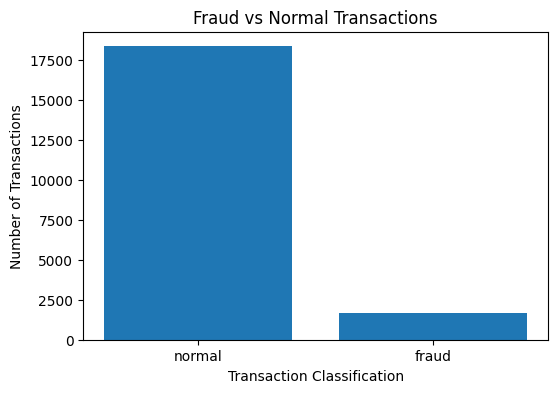

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    plot_data["fraud_flag"],
    plot_data["transaction_count"]
)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Classification")
plt.ylabel("Number of Transactions")

plt.show()

### **Step 15. Visualization 2 — Fraud by Type**

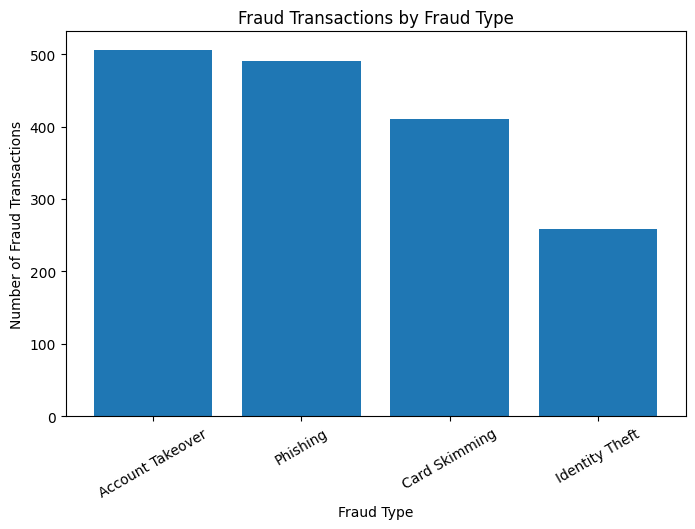

In [ ]:
type_data = fraud_by_type.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    type_data["fraud_type"],
    type_data["fraud_transactions"]
)

plt.title("Fraud Transactions by Fraud Type")
plt.xlabel("Fraud Type")
plt.ylabel("Number of Fraud Transactions")

plt.xticks(rotation=30)

plt.show()

### **Step 16. Visualization 3 — Top Fraud Accounts**

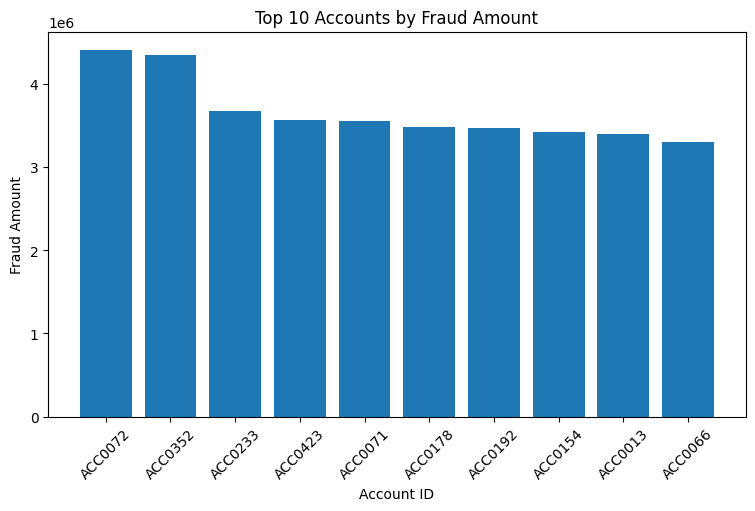

In [ ]:
account_data = top_accounts.toPandas()

plt.figure(figsize=(9, 5))

plt.bar(
    account_data["account_id"].astype(str),
    account_data["fraud_amount"]
)

plt.title("Top 10 Accounts by Fraud Amount")
plt.xlabel("Account ID")
plt.ylabel("Fraud Amount")

plt.xticks(rotation=45)

plt.show()

### **Step 17. Visualization 4 — Risk Distribution**

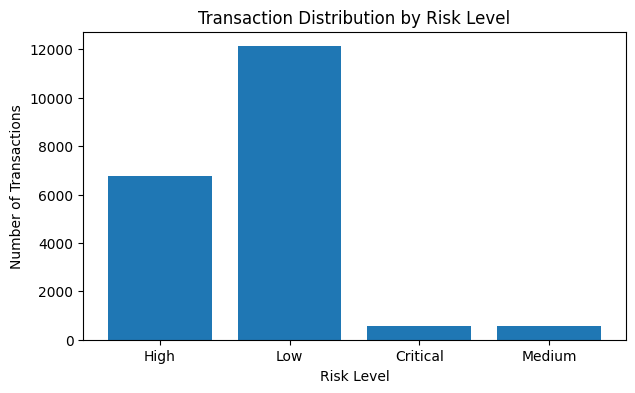

In [ ]:
risk_data = risk_summary.toPandas()

plt.figure(figsize=(7, 4))

plt.bar(
    risk_data["risk_level"],
    risk_data["transaction_count"]
)

plt.title("Transaction Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")

plt.show()

### **Step 18. Final Validation**

In [ ]:
print("========== FINAL VALIDATION ==========")

print(
    "Total records:",
    gold_transactions.count()
)

print(
    "Null transaction IDs:",
    gold_transactions.filter(
        col("txn_id").isNull()
    ).count()
)

print(
    "Null account IDs:",
    gold_transactions.filter(
        col("account_id").isNull()
    ).count()
)

print(
    "Null fraud flags:",
    gold_transactions.filter(
        col("fraud_flag").isNull()
    ).count()
)

print(
    "Duplicate transaction IDs:",
    gold_transactions
    .groupBy("txn_id")
    .count()
    .filter(col("count") > 1)
    .count()
)

========== FINAL VALIDATION ==========
Total records: 20004
Null transaction IDs: 0
Null account IDs: 0
Null fraud flags: 0
Duplicate transaction IDs: 0


### **Step 19. Export Final Analytics**

In [ ]:
import os
import shutil
from google.colab import files

# Create output directory
os.makedirs("final_analytics", exist_ok=True)

# ------------------------------------------------------------
# 1. Fraud Summary
# ------------------------------------------------------------

fraud_summary_pd = overall_summary.toPandas()

fraud_summary_path = "final_analytics/fraud_summary.csv"

fraud_summary_pd.to_csv(
    fraud_summary_path,
    index=False
)

# ------------------------------------------------------------
# 2. Fraud by Type
# ------------------------------------------------------------

fraud_by_type_pd = fraud_by_type.toPandas()

fraud_by_type_path = "final_analytics/fraud_by_type.csv"

fraud_by_type_pd.to_csv(
    fraud_by_type_path,
    index=False
)

# ------------------------------------------------------------
# 3. Top Fraud Accounts
# ------------------------------------------------------------

top_accounts_pd = top_accounts.toPandas()

top_accounts_path = "final_analytics/top_fraud_accounts.csv"

top_accounts_pd.to_csv(
    top_accounts_path,
    index=False
)

# ------------------------------------------------------------
# 4. Fraud by Merchant
# ------------------------------------------------------------

fraud_by_merchant_pd = fraud_by_merchant.toPandas()

fraud_by_merchant_path = "final_analytics/fraud_by_merchant.csv"

fraud_by_merchant_pd.to_csv(
    fraud_by_merchant_path,
    index=False
)

# ------------------------------------------------------------
# 5. Risk Summary
# ------------------------------------------------------------

risk_summary_pd = risk_summary.toPandas()

risk_summary_path = "final_analytics/risk_summary.csv"

risk_summary_pd.to_csv(
    risk_summary_path,
    index=False
)

# ------------------------------------------------------------
# Verify Files
# ------------------------------------------------------------

print("==============================================")
print("FINAL ANALYTICS FILES CREATED")
print("==============================================")

for file_name in os.listdir("final_analytics"):
    file_path = os.path.join("final_analytics", file_name)
    print(
        file_name,
        "->",
        os.path.getsize(file_path),
        "bytes"
    )

print("==============================================")
print("All 5 CSV files created successfully.")

FINAL ANALYTICS FILES CREATED
fraud_by_type.csv -> 162 bytes
fraud_by_merchant.csv -> 240 bytes
fraud_summary.csv -> 93 bytes
risk_summary.csv -> 136 bytes
top_fraud_accounts.csv -> 409 bytes
All 5 CSV files created successfully.


### **Download the Files**

In [ ]:
files.download("final_analytics/fraud_summary.csv")

files.download("final_analytics/fraud_by_type.csv")

files.download("final_analytics/top_fraud_accounts.csv")

files.download("final_analytics/fraud_by_merchant.csv")

files.download("final_analytics/risk_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Key Business Insights**


The Gold layer analysis provides the following business insights:

1. Transactions associated with accounts present in the fraud
   watchlist are classified as fraudulent.

2. Fraud transactions can be analyzed according to fraud type,
   helping identify the major categories of suspicious activity.

3. Account-level analysis identifies accounts contributing the
   highest fraud amounts.

4. Merchant-level analysis helps identify merchants associated
   with higher fraudulent transaction activity.

5. Risk-level classification helps prioritize transactions for
   further investigation.

6. The fraud rate provides an overall measure of suspicious
   activity within the transaction dataset.

## **Conclusion**

The Gold-layer fraud detection results were analyzed using PySpark
and Spark SQL. Fraud transactions were examined by fraud type,
account, merchant and risk level.

The generated visualizations provide a clear view of fraudulent
activity and help identify high-risk accounts and transaction
patterns. The final analytical outputs can be used by business
teams for fraud monitoring and investigation.

The complete pipeline now follows:

Raw Data → Bronze → Silver → Gold → Analytics